# Introduction on Word Embeddings

In [5]:
! pip install spacy csv

ERROR: Could not find a version that satisfies the requirement csv (from versions: none)

[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for csv


In [6]:
import os
import csv
import spacy

class Corpus(object):
    def __init__(self, filename):
        self.filename = filename
        self.nlp = spacy.blank("en")
    def __iter__(self):
        with open(self.filename, "r", encoding="utf-8") as i:
            reader = csv.reader(i, delimiter=",")
            for _, abstract in reader:
                tokens = [t.text.lower() for t in self.nlp(abstract)]
                yield tokens
documents = Corpus("arxiv.csv")

In [ ]:
# documents = list(documents)
# documents[:10]

[['this',
  'paper',
  'investigates',
  'a',
  'cross',
  '-',
  'lingual',
  'document',
  'embedding',
  'method',
  'that',
  '\n',
  'improves',
  'the',
  'current',
  'neural',
  'machine',
  'translation',
  'framework',
  'based',
  'document',
  'vector',
  '\n',
  '(',
  'ntdv',
  'or',
  'simply',
  'nv',
  ')',
  '.',
  'nv',
  'is',
  'developed',
  'with',
  'a',
  'self',
  '-',
  'attention',
  'mechanism',
  'under',
  'the',
  '\n',
  'neural',
  'machine',
  'translation',
  '(',
  'nmt',
  ')',
  'framework',
  '.',
  'in',
  'nv',
  ',',
  'each',
  'pair',
  'of',
  'parallel',
  '\n',
  'documents',
  'in',
  'different',
  'languages',
  'are',
  'projected',
  'to',
  'the',
  'same',
  'shared',
  'layer',
  'in',
  'the',
  '\n',
  'model',
  '.',
  'however',
  ',',
  'the',
  'pair',
  'of',
  'nv',
  'embeddings',
  'are',
  'not',
  'guaranteed',
  'to',
  'be',
  'similar',
  '.',
  '\n',
  'this',
  'paper',
  'further',
  'adds',
  'a',
  'distance',


In [ ]:
pip install gensim #Used to create word embedding

Note: you may need to restart the kernel to use updated packages.


In [7]:
import gensim

model = gensim.models.Word2Vec(documents, min_count=100, window = 5, vector_size = 100)

In [8]:
model.wv["nlp"]

array([ 0.79533434, -0.33677453,  1.6915193 , -0.93643546,  0.07787584,
       -0.2827152 ,  1.7211806 ,  0.6216036 , -0.6970171 ,  0.487445  ,
       -0.31093287, -1.7297211 ,  1.1464194 ,  0.54065883,  0.1575121 ,
       -0.58043367,  0.19605288,  1.7204964 , -0.88895327,  1.1874211 ,
        0.53091913,  0.3663506 ,  1.0852144 , -0.07682681, -1.7697039 ,
       -1.0782666 ,  1.8414364 ,  1.6212044 ,  2.1203506 ,  0.5815012 ,
        1.7454723 ,  0.24012841,  1.1564406 ,  1.0715036 ,  0.8289957 ,
       -1.6269404 , -0.03485772, -3.8008285 ,  0.6826076 ,  2.5523667 ,
       -1.7233359 , -1.396377  ,  3.1955054 ,  2.3258116 , -1.1694179 ,
        0.80333865,  2.1141593 ,  1.3063052 , -0.44821543, -1.9393408 ,
        1.774793  ,  1.159372  ,  1.2653528 ,  0.1028032 ,  2.1773264 ,
        0.34528807,  0.00708184,  1.1873336 ,  3.5653734 , -0.43019673,
        0.5231252 ,  1.953627  , -1.1487275 , -1.5131052 ,  0.5377381 ,
        0.19837587, -1.355476  , -2.1163375 ,  0.5778019 , -0.81

In [13]:
print(model.wv.similarity("nmt", "smt"))

0.66288215


In [14]:
model.wv.

SyntaxError: invalid syntax (2997056799.py, line 1)

In [20]:
model.wv.most_similar(positive = ["transformer", "lstm"], negative=["bert"], topn= 3)

[('rnn', 0.8422657251358032),
 ('gru', 0.7661519646644592),
 ('recurrent', 0.7555282711982727)]

# Plot Embeddings

In [26]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

target_word = "bert"
selected_words = [w[0] for w in model.wv.most_similar(positive=[target_word], topn = 200)] + [target_word]
embeddings = [model.wv[w] for w in selected_words] + model.wv["bert"]
mapped_embedding = TSNE(n_components=2, metric="cosine", init="pca").fit_transform(embeddings)

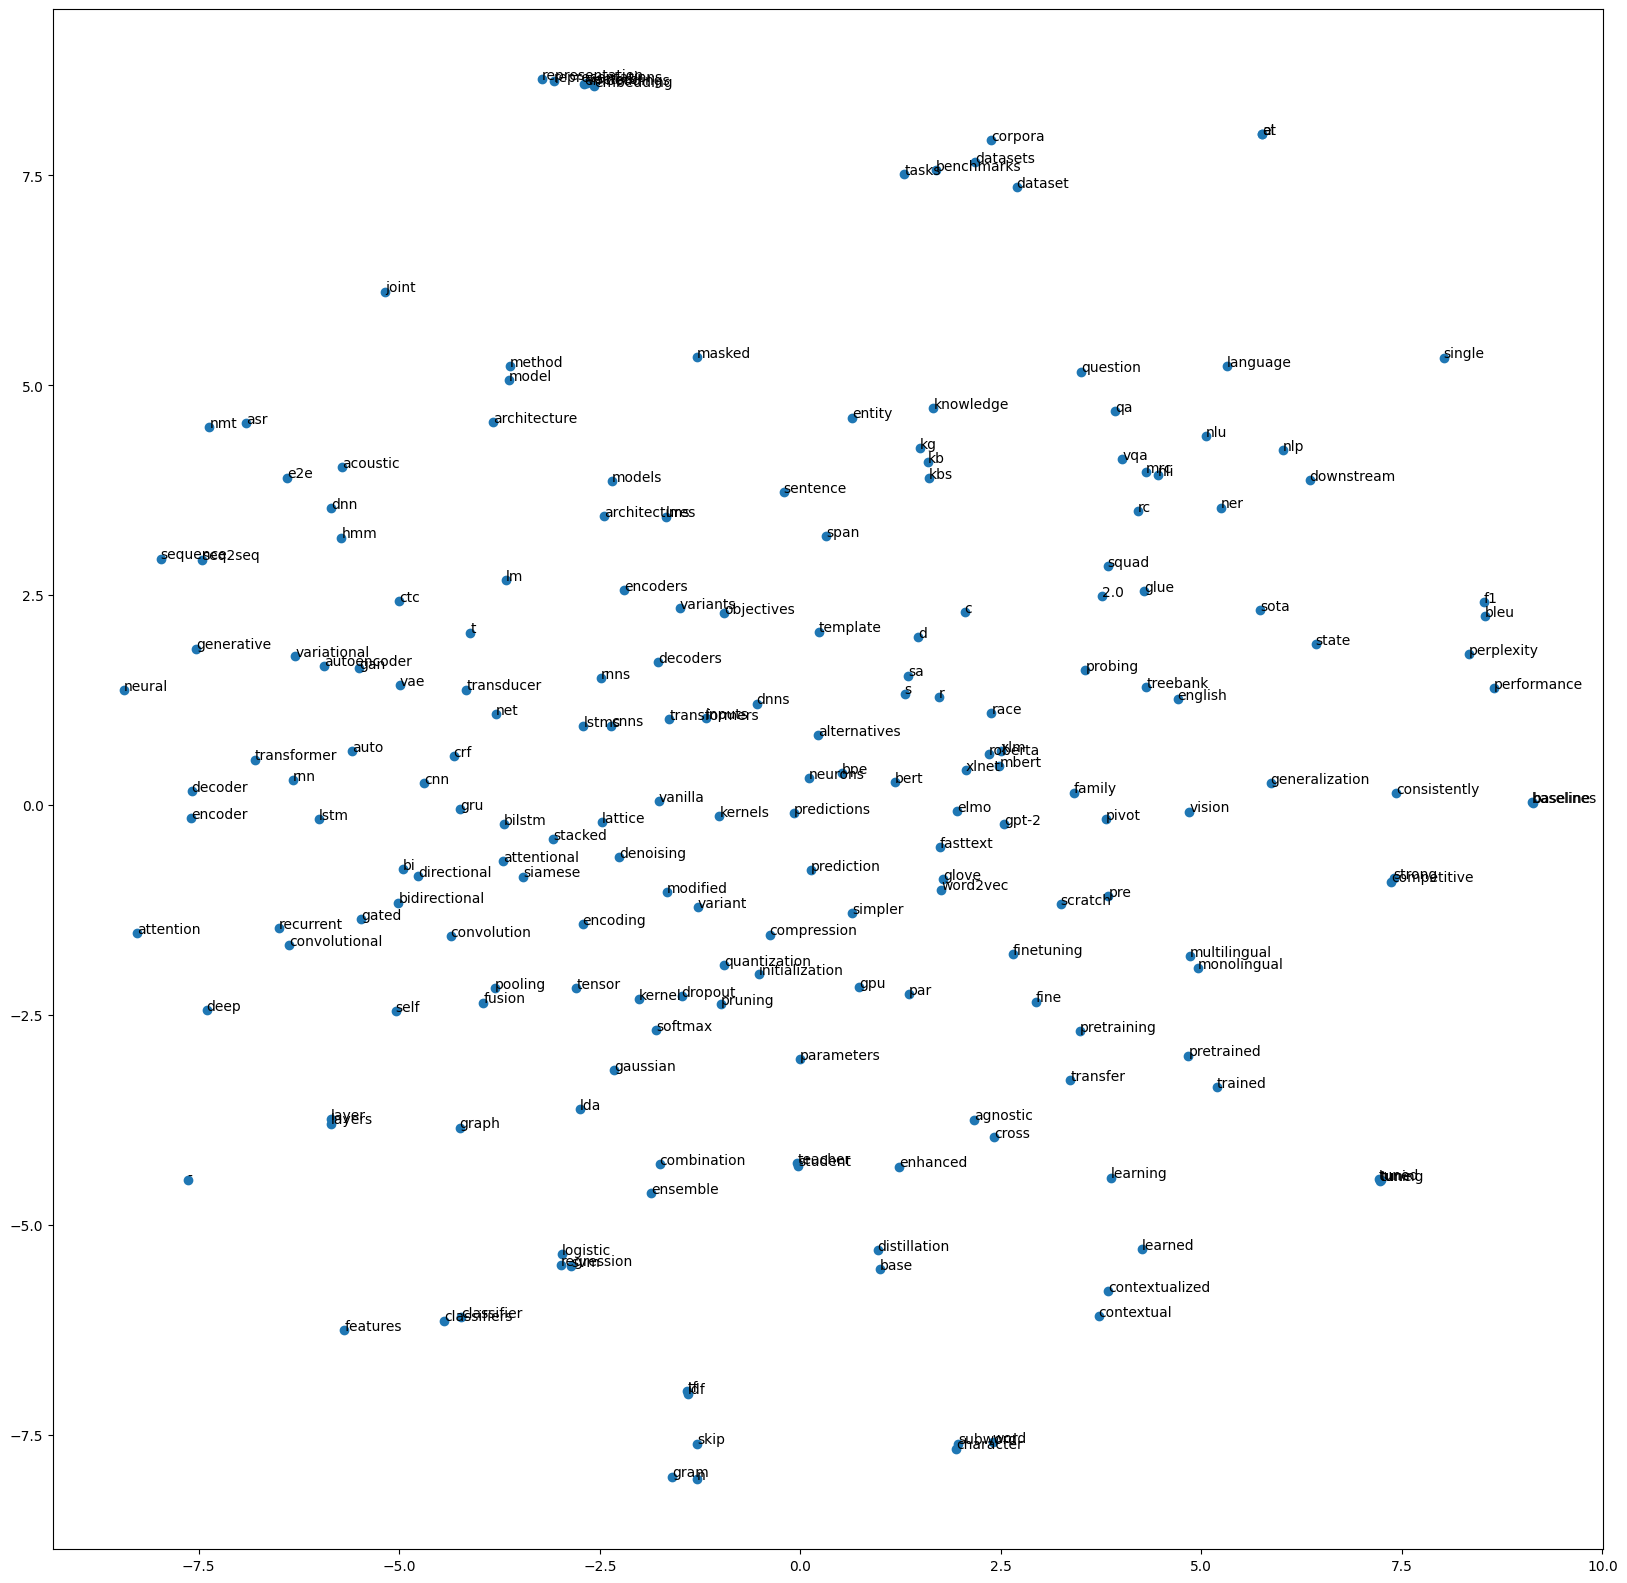

In [27]:
plt.figure(figsize=[20, 20])
x = mapped_embedding[:,0]
y = mapped_embedding[:, 1]
plt.scatter(x,y)

for i, txt in enumerate(selected_words):
    plt.annotate(txt, (x[i], y[i]))